STOCK PRICE PREDICTION IN PYTHON WITH PYTORCH

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


<Axes: >

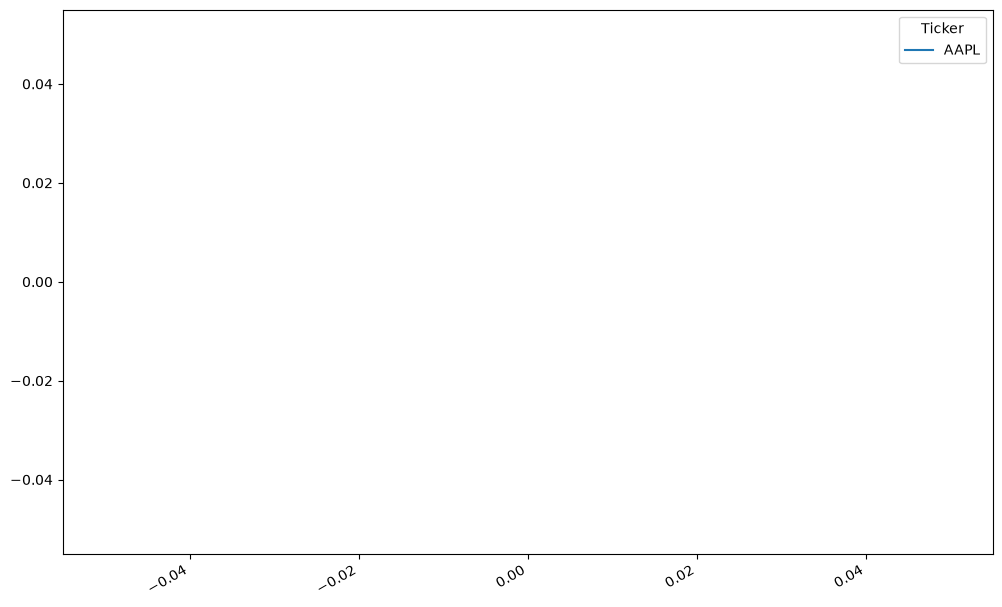

In [12]:
df.Close.plot(figsize=(12,8))

In [14]:
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df['Close'])
df.Close

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by StandardScaler.

In [19]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i*seq_length])

data = np.array(data)

In [42]:
train_size = int(0.8* len(data)) #80%
x_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
x_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

In [43]:
class PredictionModel(nn.Module):
    def _init_(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self)._init_()
        self.num_layer = num_layers
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self,x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out


In [44]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

TypeError: PredictionModel.__init__() got an unexpected keyword argument 'input_dim'

In [45]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

NameError: name 'model' is not defined

In [46]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)
    if i % 25 == 0:
        print(i, loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


NameError: name 'model' is not defined

In [47]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

NameError: name 'model' is not defined

In [48]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:,0], y_test_pred[:, 0])

NameError: name 'y_train' is not defined

NameError: name 'y_test' is not defined

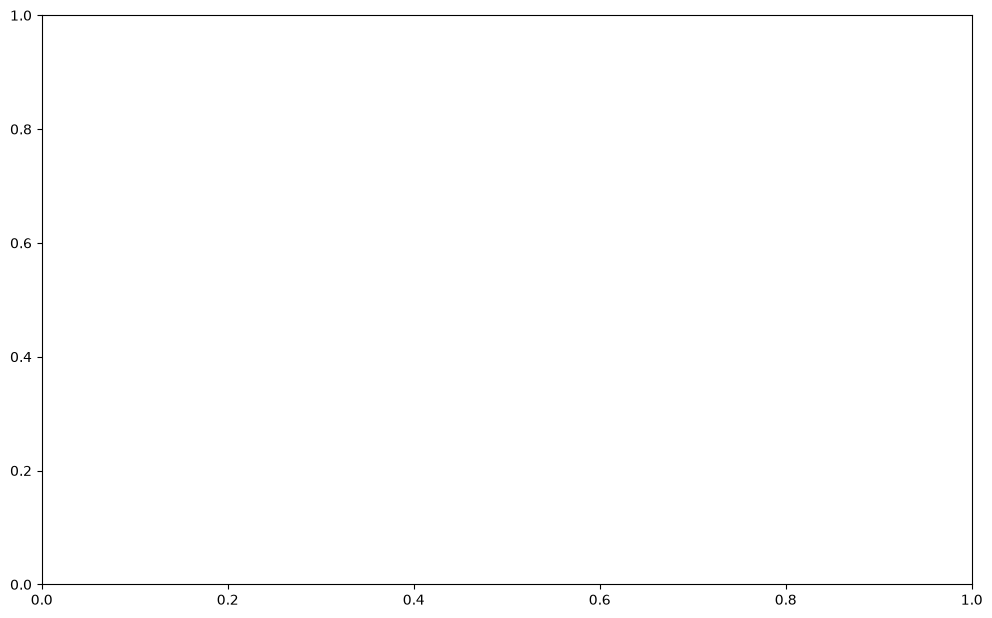

In [51]:
fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')
ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = 'blue', linestyle = '--', label = 'RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plit.show()